In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn
libreria de python pensada para visualizacion de datos estadisticos. esta construida sobre matploty y se integra de forma nativa con pandas. tiene graficas mas complejas y visuales que su hermana pequeña matploty.

se usa mucho en los analisis exploratorios de datos (EDA), en proyectos de ciencia de datos.

## 1.grafico de lineas categorizado (sns.luneplot)
**casos de uso**: comparar la evolucion de una variable a lo largo del tiempo, pero separada por categorias.
**data model**: necesitamos una tabla o dataframe con columnas: tiempo, valor numerico y categoria para poder hacer una agrupacion

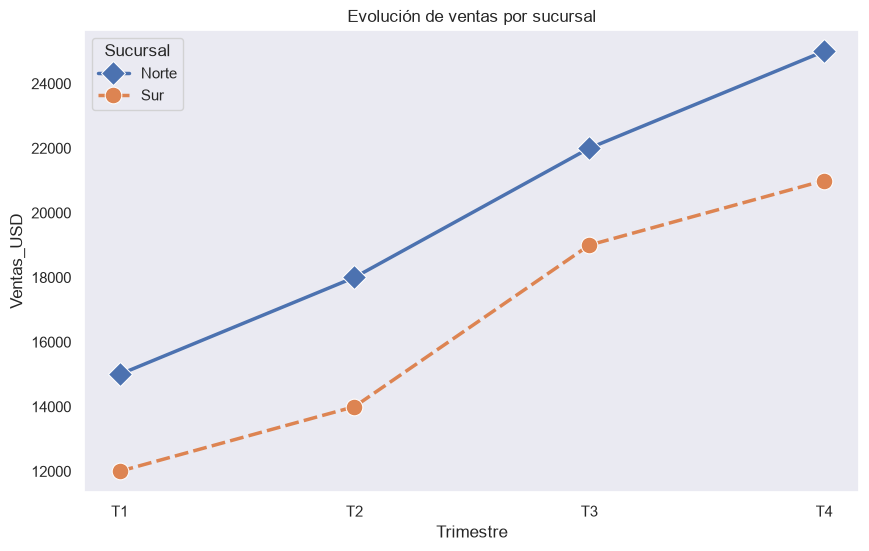

In [10]:
datos = {
    "Trimestre": ["T1", "T2", "T3", "T4", "T1", "T2", "T3", "T4"],
    "Ventas_USD": [15000, 18000, 22000, 25000, 12000, 14000, 19000, 21000],
    "Sucursal": ["Norte", "Norte", "Norte", "Norte", "Sur", "Sur", "Sur", "Sur"]
}

df = pd.DataFrame(datos)

sns.set_theme(style='dark')
plt.figure(figsize=(10,6))
plt.title('Evolución de ventas por sucursal')

sns.lineplot(
        data=df, 
        x="Trimestre", 
        y="Ventas_USD", 
        hue="Sucursal", 
        style="Sucursal",
        markers={ 'Norte': 'D', 'Sur': 'o' },
        markersize= 12,
        linewidth=2.5
        )

plt.xlabel = 'Trimestre'
plt.ylabel = 'Ventas'
plt.show()

## 2.grafico de barras agrupado (sns.barplot)

**casos de uso**: compara valores promedio (valores agregados) de diferentes categorias divididas en subgrupos.
**data model**: ehe X categorias primarias que queremos evaluar. eje Y valores que queremos comparar numericos. (hue subcategorias).

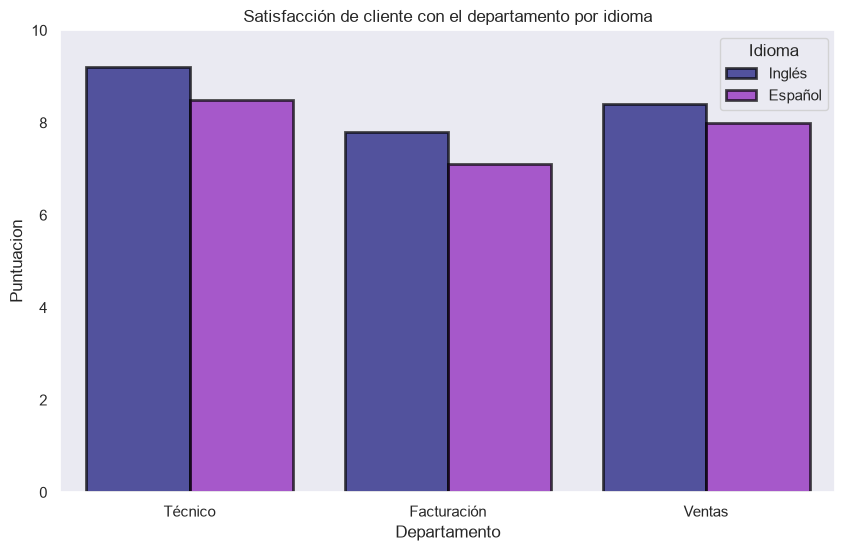

In [11]:
datos_soporte = {
    "Departamento": ["Técnico", "Técnico", "Facturación", "Facturación", "Ventas", "Ventas"],
    "Puntuacion": [8.5, 9.2, 7.1, 7.8, 8.0, 8.4],
    "Idioma": ["Español", "Inglés", "Español", "Inglés", "Español", "Inglés"]
}

df_soporte = pd.DataFrame(datos_soporte)

plt.figure(figsize=(10,6))
plt.title('Satisfacción de cliente con el departamento por idioma')
# este grafico tiene la posibilidad de ponerle una escala
plt.ylim(0, 10) # escala de 0 a 10

sns.barplot(data=df_soporte, x='Departamento', y="Puntuacion", hue="Idioma", edgecolor='black', linewidth=2, alpha=0.7, hue_order=['Inglés', 'Español'], dodge=True, palette=['darkblue', 'darkviolet'])

plt.show()

## 3.grafico de dispersion relacional (sns.scatterplot)

**casos de uso**: visualizar relaciones entre dos variables cuantitativas y agregar dimensiones adicionales.
**data model**: coordenadas X e Y numericas.

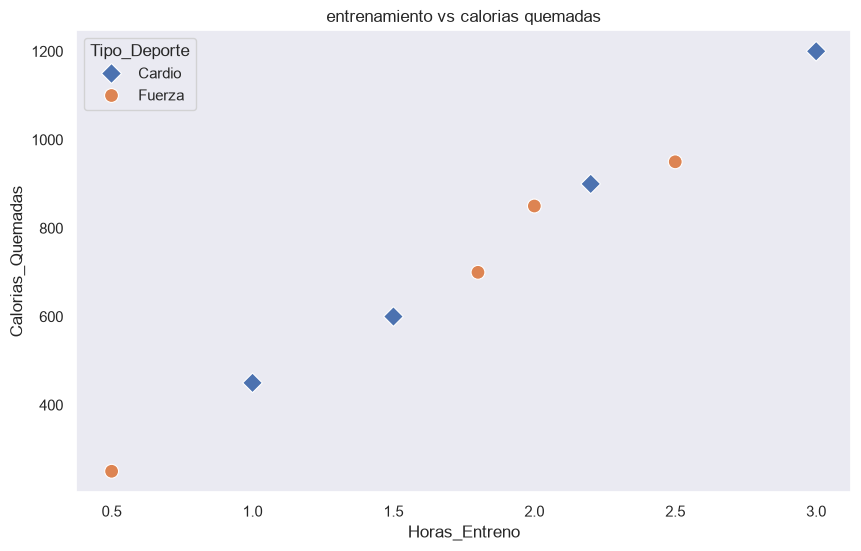

In [12]:
datos_deporte = {
    "Horas_Entreno": [1.5, 2.0, 1.0, 3.0, 2.5, 0.5, 2.2, 1.8],
    "Calorias_Quemadas": [600, 850, 450, 1200, 950, 250, 900, 700],
    "Tipo_Deporte": ["Cardio", "Fuerza", "Cardio", "Cardio", "Fuerza", "Fuerza", "Cardio", "Fuerza"]
}

df_deporte = pd.DataFrame(datos_deporte)

plt.figure(figsize=(10,6))
plt.title('entrenamiento vs calorias quemadas')
sns.scatterplot(data=df_deporte, x='Horas_Entreno', y='Calorias_Quemadas', hue='Tipo_Deporte', s=100, style='Tipo_Deporte', markers=['D', 'o'])
plt.show()

## 4. histograma con densidad (sns.histplot)

**casos de uso**: mostrar distribucion de datos con una curva que suavice dicha distribucion (KDE) que facilita ver los picos y la concentracion (todo lo que quede debajo de la curva).
**data model**: un unico listado numerico, ya que medimos repeticion y concentracion.

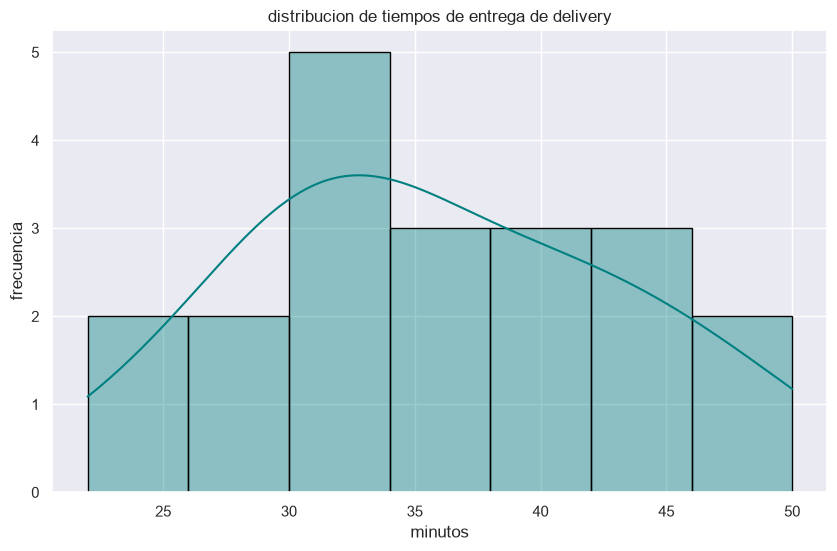

In [13]:
# Dataset: Tiempos de entrega de comida a domicilio (en minutos)


tiempos = [22, 25, 28, 30, 31, 32, 33, 35, 38, 40, 41, 42, 45, 48, 50, 29, 31, 35, 36, 44]

df_tiempos = pd.DataFrame( {"tiempo_minutos": tiempos } )

plt.figure(figsize=(10,6))
plt.title('distribucion de tiempos de entrega de delivery')
hist = sns.histplot(data=df_tiempos, x='tiempo_minutos', color='teal', alpha=0.4, bins=7, edgecolor='black', kde=True)
hist.set_xlabel('minutos')
hist.set_ylabel('frecuencia')
plt.grid()
plt.show()

## 5.diagrama de caja (sns.boxplot)

**caso de uso**: visualizacion de distribuciones estadisticas (mediana, outliner, rango intercuartil) comprarando multiples grupos.

**data model** columna en eje X que sea la categorizacion y una columna numerica en eje Y.

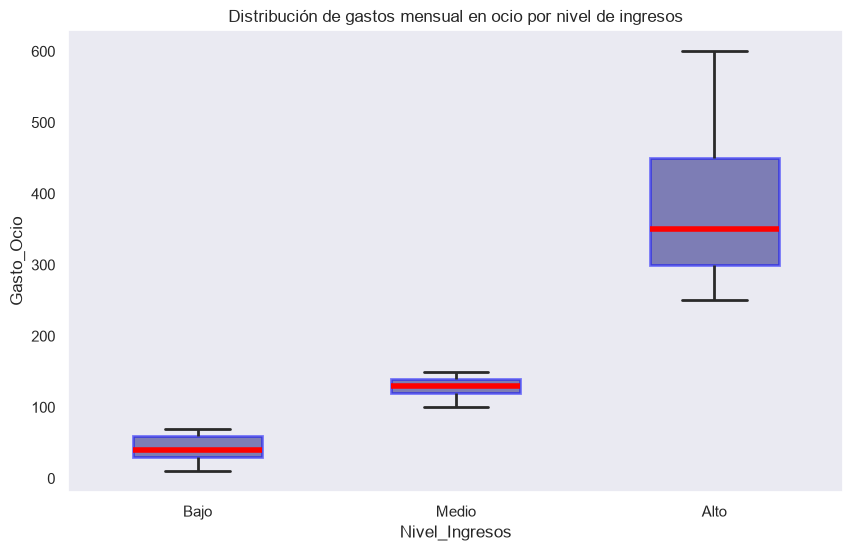

In [14]:
# Dataset: Gasto mensual en ocio agrupado por nivel de ingresos del usuario
datos_ocio = {
    "Nivel_Ingresos": ["Bajo"]*5 + ["Medio"]*5 + ["Alto"]*5,
    "Gasto_Ocio": [
        10, 60, 40, 70, 30,          # Ingreso Bajo
        120, 150, 100, 130, 140,     # Ingreso Medio
        300, 450, 250, 350, 600      # Ingreso Alto (600 es un valor atípico alto)
    ]
}
df_ocio = pd.DataFrame(datos_ocio)

plt.figure(figsize=(10,6))
plt.title('Distribución de gastos mensual en ocio por nivel de ingresos')
sns.boxplot(data=df_ocio, x="Nivel_Ingresos", y="Gasto_Ocio", width=0.5, linewidth=2, medianprops={'color': 'red', 'linewidth': 4}, color='darkblue', boxprops={'alpha': 0.5, 'edgecolor': 'blue'})
plt.show()

## 6.diagrama de violin (sns.violinplot)

**caso de uso**: similar al boxplot pero muestra la densidad de probabilidad para ver de forma clara si la distribucion es bimodal (dos picos).

**data model**: eje X categoria (cualitativo), eje Y un valor numerico.

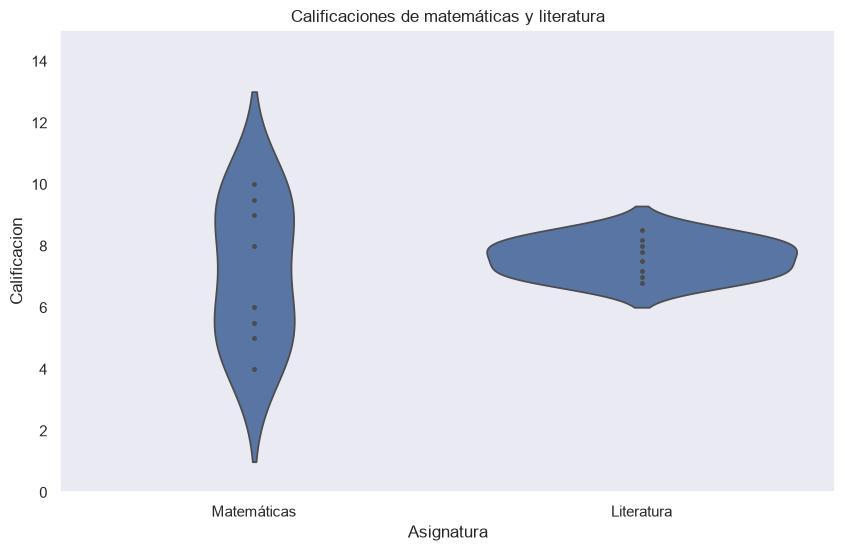

In [15]:
datos_clase = {
    "Asignatura": ["Matemáticas"]*8 + ["Literatura"]*8,
    "Calificacion": [
        4, 5, 5.5, 6, 8, 9, 9.5, 10,       # Matemáticas (distribución dispersa)
        7, 7.5, 7.2, 8, 8.2, 7.8, 6.8, 8.5  # Literatura (muy concentrada alrededor de 7.5-8)
    ]
}

df_clase = pd.DataFrame(datos_clase)

plt.figure(figsize=(10,6))
plt.title('Calificaciones de matemáticas y literatura')
plt.ylim(0,15)
sns.violinplot(data=df_clase, x="Asignatura", y="Calificacion", inner='point')
# inner 'box' (caja por defecto), 'quartile' (líneas de cuartiles), 'point' (puntos exactos), 'stick' (palitos)
plt.show()

## 7. Mapa de calor (sns.heatmap)

**Casos de uso**: Visualizar matrices numericas (multidata) asignado variaciones de color segun la intensidad de valor

**Data Model**: Matriz cuadrada (3x3)

                 Horas_Sueno  Minutos_Deporte  Cafes_Dia
Horas_Sueno         1.000000        -0.545239  -1.000000
Minutos_Deporte    -0.545239         1.000000   0.545239
Cafes_Dia          -1.000000         0.545239   1.000000


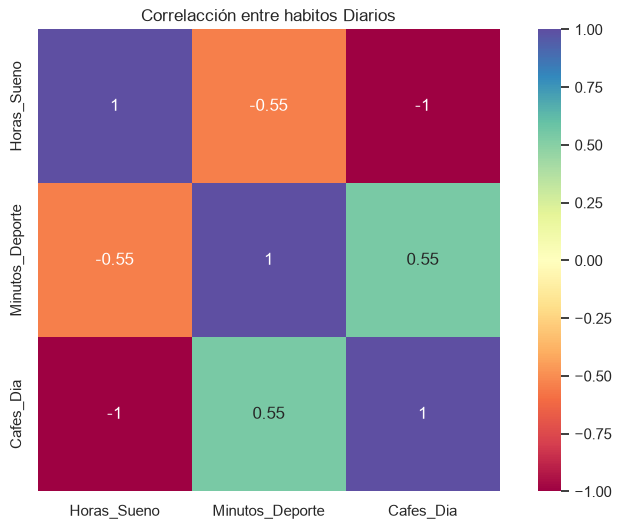

In [18]:
habitos = {
    "Horas_Sueno": [8, 7, 6, 8, 5, 7, 6, 9, 5, 8],
    "Minutos_Deporte": [45, 30, 60, 0, 15, 45, 20, 10, 90, 0],
    "Cafes_Dia": [1, 2, 3, 1, 4, 2, 3, 0, 4, 1]
}

df_habitos = pd.DataFrame(habitos)

# sacar matriz de correlacion lineal: es una tabla que cruza todas las columnas numericas para medir como se relacionan entre si matematicamente

# coeficiente de pearson (r) para cada par de variables. este valor siempre va entre -1 y 1
    # cerca del 1 (correlacion positiva): si una variable sube la otra tambien (altura y peso)
    # cerca de -1 (correlacion negativa): si una variable sube la otra baja (velocidad y duracion de viaje)
    # cerca del 0 ( sin correlacion): No hay ninguna relacion entre esas dos variables. Los puntos parecen nube desordenada.

matriz_correlacion = df_habitos.corr()
print(matriz_correlacion)

plt.figure(figsize=(10,6))
plt.title('Correlacción entre habitos Diarios')
sns.heatmap(data=matriz_correlacion, cmap="Spectral", annot=True, square=True)
#. cmap Spectral, vlag, coolwarm 
plt.show()